# Explainable CNN-Based Diabetic Retinopathy Detection with Vessel-Aware Preprocessing
### Phase 1 MVP Deliverable

**Project Summary:**
This pipeline implements an end-to-end Explainable Deep Learning system for 5-class Diabetic Retinopathy (DR) grading on the International Clinical Diabetic Retinopathy (ICDR) scale:
- **Grade 0:** No DR
- **Grade 1:** Mild NPDR
- **Grade 2:** Moderate NPDR
- **Grade 3:** Severe NPDR
- **Grade 4:** Proliferative DR (PDR)

**Key Innovations:**
1. **Vessel-Aware Preprocessing:** Pretrained / multi-scale vascular feature extraction providing a dedicated vessel probability map.
2. **4-Channel CNN Fusion:** ImageNet-pretrained backbone adapted to accept 4 channels ($[R, G, B, V]$) via channel-stacking.
3. **Explainability Layer:** Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize retinal regions influencing diagnostic decisions.

In [1]:
import os
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Add project root to sys.path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

from src.preprocessing import crop_fundus_circle, apply_clahe, preprocess_fundus
from src.vessel_segmentation import VesselSegmenter, extract_vessel_map_multiscale
from src.dataset import APTOSDataset, create_dataloaders
from src.models import build_model
from src.train import train_model
from src.evaluate import evaluate_model, plot_confusion_matrix
from src.explainability import GradCAM, overlay_cam_on_image
from src.utils import generate_synthetic_fundus, setup_sample_dataset, plot_prediction_explanation

# Configure environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using compute device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
plt.rcParams['figure.dpi'] = 120


Using compute device: cuda
GPU: NVIDIA GeForce GTX 1650


## 1. Data Pipeline: Dataset Setup & Preprocessing (Chunk 1)
Raw fundus photography typically exhibits dark unilluminated margins and uneven exposure across retinal zones.
Here we load the dataset and apply **circular crop** (black border removal) and **CLAHE** (Contrast Limited Adaptive Histogram Equalization) on LAB color space to enhance microaneurysms, hemorrhages, and vascular branches.

Generated sample dataset: 100 images at sample_data with 5 balanced classes.
Dataset summary: 100 images


,id_code,diagnosis
0,fundus_0_000,0
1,fundus_0_001,0
2,fundus_0_002,0
3,fundus_0_003,0
4,fundus_0_004,0


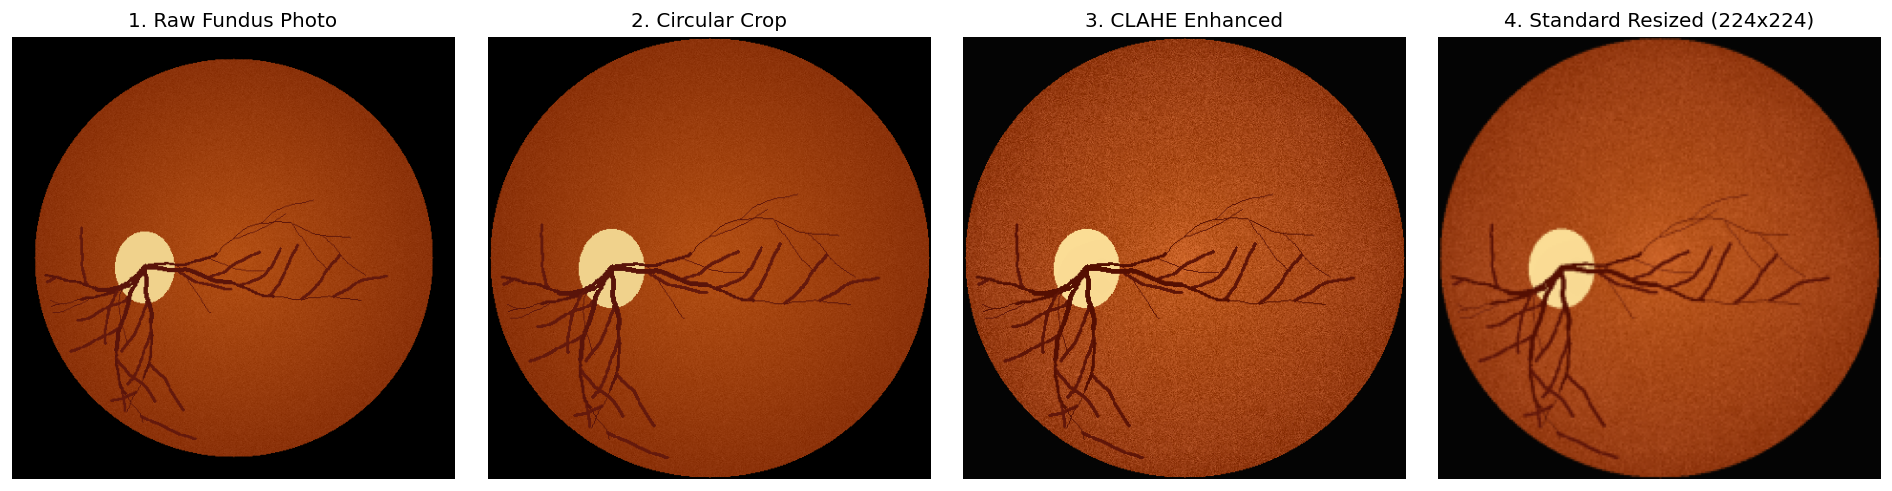

In [2]:
# Setup sample dataset
data_dir, df = setup_sample_dataset(output_dir='sample_data', num_samples_per_class=20)
images_dir = data_dir / 'images'

print(f'Dataset summary: {len(df)} images')
display(df.head())

# Visual comparison: Raw vs Cropped vs CLAHE-enhanced
sample_raw = cv2.imread(str(images_dir / f"{df.iloc[0]['id_code']}.png"))
sample_raw = cv2.cvtColor(sample_raw, cv2.COLOR_BGR2RGB)

sample_cropped = crop_fundus_circle(sample_raw)
sample_clahe = apply_clahe(sample_cropped)
sample_preprocessed = preprocess_fundus(sample_raw, target_size=(224, 224))

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(sample_raw)
axs[0].set_title('1. Raw Fundus Photo')
axs[0].axis('off')

axs[1].imshow(sample_cropped)
axs[1].set_title('2. Circular Crop')
axs[1].axis('off')

axs[2].imshow(sample_clahe)
axs[2].set_title('3. CLAHE Enhanced')
axs[2].axis('off')

axs[3].imshow(sample_preprocessed)
axs[3].set_title('4. Standard Resized (224x224)')
axs[3].axis('off')

plt.tight_layout()
plt.show()


### Data Pipeline Insights:
- **Circular Crop:** Eliminates non-informative black borders, optimizing the active pixel density for the convolutional receptive field.
- **Adaptive Equalization (CLAHE):** Enhances micro-vascular boundaries and localized hemorrhage edges without blowing out optic disc saturation.

## 2. Vessel Segmentation & Feature Caching (Chunk 3)
Extracting vascular probability maps ($V \in [0, 1]$) to supply explicit morphological priors directly to the classifier.

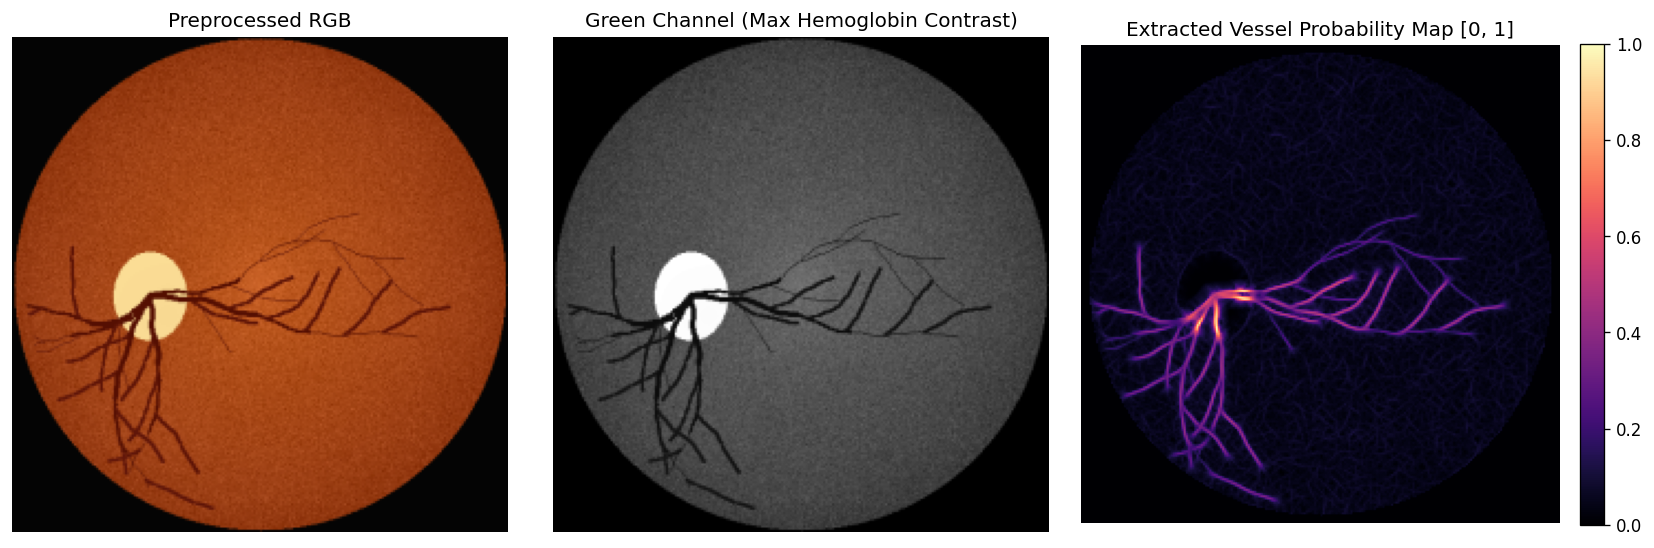

In [3]:
vessel_cache_dir = Path('outputs/vessel_cache')
segmenter = VesselSegmenter(cache_dir=vessel_cache_dir)

# Extract vessel map for sample fundus
vessel_map = segmenter.get_vessel_map(sample_preprocessed, image_id='demo_sample', target_size=(224, 224))

fig, axs = plt.subplots(1, 3, figsize=(14, 4.5))
axs[0].imshow(sample_preprocessed)
axs[0].set_title('Preprocessed RGB')
axs[0].axis('off')

axs[1].imshow(sample_preprocessed[:, :, 1], cmap='gray')
axs[1].set_title('Green Channel (Max Hemoglobin Contrast)')
axs[1].axis('off')

im = axs[2].imshow(vessel_map, cmap='magma', vmin=0, vmax=1)
axs[2].set_title('Extracted Vessel Probability Map [0, 1]')
axs[2].axis('off')
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 3. 4-Channel Model Architecture (Chunk 4)
We adapt the first convolutional layer (`conv1`) of an ImageNet-pretrained ResNet-18 backbone:
- Original weights $W_{RGB} \in \mathbb{R}^{64 \times 3 \times 7 \times 7}$ are preserved for channels 0, 1, and 2.
- Channel 3 (vessel map) is initialized with the channel-wise mean of $W_{RGB}$.

In [4]:
model_4ch = build_model(model_type='vessel_aware', backbone='resnet18', num_classes=5, pretrained=True)

print('Vessel-Aware ResNet-18 Conv1 Configuration:')
print(model_4ch.backbone.conv1)
print(f'Conv1 weight tensor shape: {model_4ch.backbone.conv1.weight.shape}')
print('Classification Head:')
print(model_4ch.backbone.fc)


Vessel-Aware ResNet-18 Conv1 Configuration:
Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Conv1 weight tensor shape: torch.Size([64, 4, 7, 7])
Classification Head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=5, bias=True)
)


## 4. Model Training & Evaluation (Chunks 2 & 4)
Training both the Baseline (3ch) and Vessel-Aware (4ch) CNNs with class-weighted cross-entropy loss.

In [5]:
# Create DataLoaders
train_loader_3ch, val_loader_3ch, class_weights = create_dataloaders(
    df=df, image_dir=images_dir, val_split=0.2, batch_size=16, is_4channel=False, vessel_cache_dir=vessel_cache_dir
)
train_loader_4ch, val_loader_4ch, _ = create_dataloaders(
    df=df, image_dir=images_dir, val_split=0.2, batch_size=16, is_4channel=True, vessel_cache_dir=vessel_cache_dir
)

# Train Baseline Model
print('=== Training Baseline 3-Channel CNN ===')
baseline_model = build_model(model_type='baseline', backbone='resnet18', num_classes=5, pretrained=True)
hist_baseline = train_model(
    model=baseline_model,
    train_loader=train_loader_3ch,
    val_loader=val_loader_3ch,
    num_epochs=5,
    learning_rate=3e-4,
    class_weights=class_weights,
    device=str(device)
)

# Train Vessel-Aware Model
print('\n=== Training Vessel-Aware 4-Channel CNN ===')
vessel_model = build_model(model_type='vessel_aware', backbone='resnet18', num_classes=5, pretrained=True)
hist_vessel = train_model(
    model=vessel_model,
    train_loader=train_loader_4ch,
    val_loader=val_loader_4ch,
    num_epochs=5,
    learning_rate=3e-4,
    class_weights=class_weights,
    device=str(device)
)


=== Training Baseline 3-Channel CNN ===


Starting training on device: cuda for 5 epochs...


Epoch [01/05] Train Loss: 1.2848 | Train Acc: 0.4750 | Val Loss: 1.1693 | Val Acc: 0.3500


Epoch [02/05] Train Loss: 0.3455 | Train Acc: 0.8500 | Val Loss: 0.4460 | Val Acc: 0.9000


Epoch [03/05] Train Loss: 0.2315 | Train Acc: 0.9250 | Val Loss: 0.2506 | Val Acc: 0.9000


...

Epoch [01/05] Train Loss: 1.3020 | Train Acc: 0.3625 | Val Loss: 0.7715 | Val Acc: 0.6000


Epoch [02/05] Train Loss: 0.5347 | Train Acc: 0.7875 | Val Loss: 0.5515 | Val Acc: 0.8000


Epoch [03/05] Train Loss: 0.2921 | Train Acc: 0.9000 | Val Loss: 0.3845 | Val Acc: 0.8500


Epoch [04/05] Train Loss: 0.2537 | Train Acc: 0.9000 | Val Loss: 0.2764 | Val Acc: 0.8500


Epoch [05/05] Train Loss: 0.2241 | Train Acc: 0.9000 | Val Loss: 0.2387 | Val Acc: 0.8500
Training complete. Best Validation Accuracy: 0.8500


Vessel-Aware Model Accuracy: 85.00%

Classification Report:
                   precision    recall  f1-score   support

        0 - No DR       0.60      0.75      0.67         4
         1 - Mild       0.67      0.50      0.57         4
     2 - Moderate       1.00      1.00      1.00         4
       3 - Severe       1.00      1.00      1.00         4
4 - Proliferative       1.00      1.00      1.00         4

         accuracy                           0.85        20
        macro avg       0.85      0.85      0.85        20
     weighted avg       0.85      0.85      0.85        20



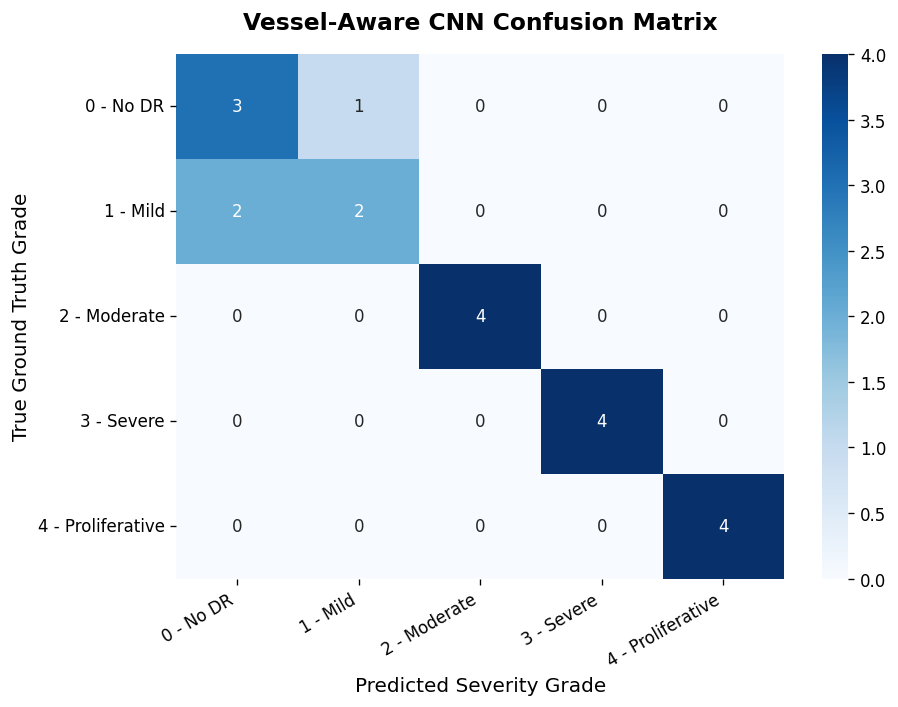

In [6]:
# Evaluate and Compare
eval_res = evaluate_model(vessel_model, val_loader_4ch, device=str(device))
print(f'Vessel-Aware Model Accuracy: {eval_res["accuracy"]*100:.2f}%')
print('\nClassification Report:')
print(eval_res['classification_report'])

# Plot Confusion Matrix
plot_confusion_matrix(eval_res['confusion_matrix'], title='Vessel-Aware CNN Confusion Matrix')
plt.show()


## 5. Explainability & Grad-CAM Demo Visualizations (Chunk 5)
For each ICDR severity grade (0 to 4), we generate the 4-panel visual explanation deliverable:
$$\text{Preprocessed Fundus} \longrightarrow \text{Vessel Probability Map} \longrightarrow \text{Grad-CAM Saliency Overlay} \longrightarrow \text{Class Probabilities Bar Chart}$$

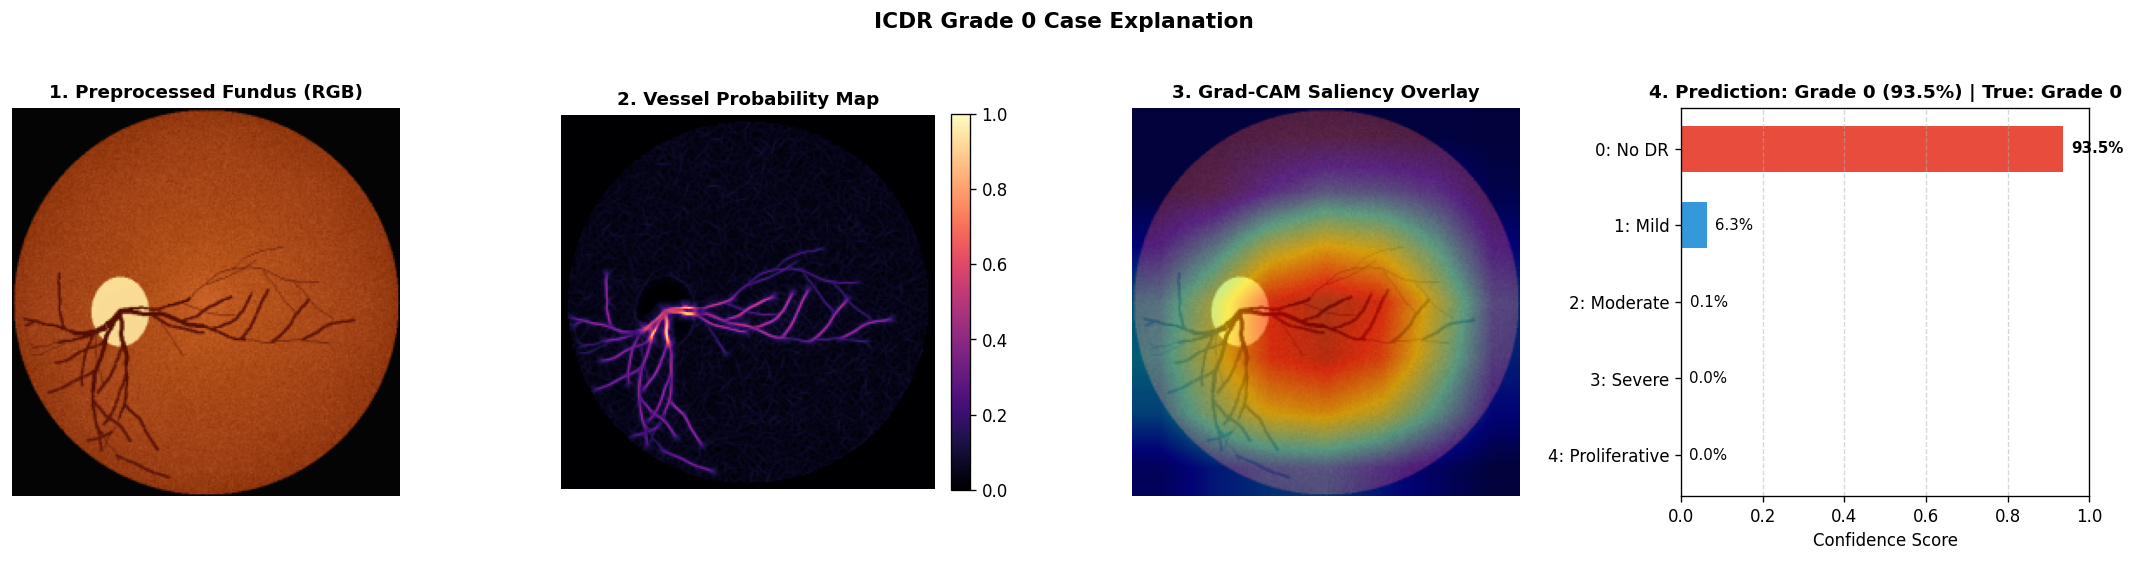

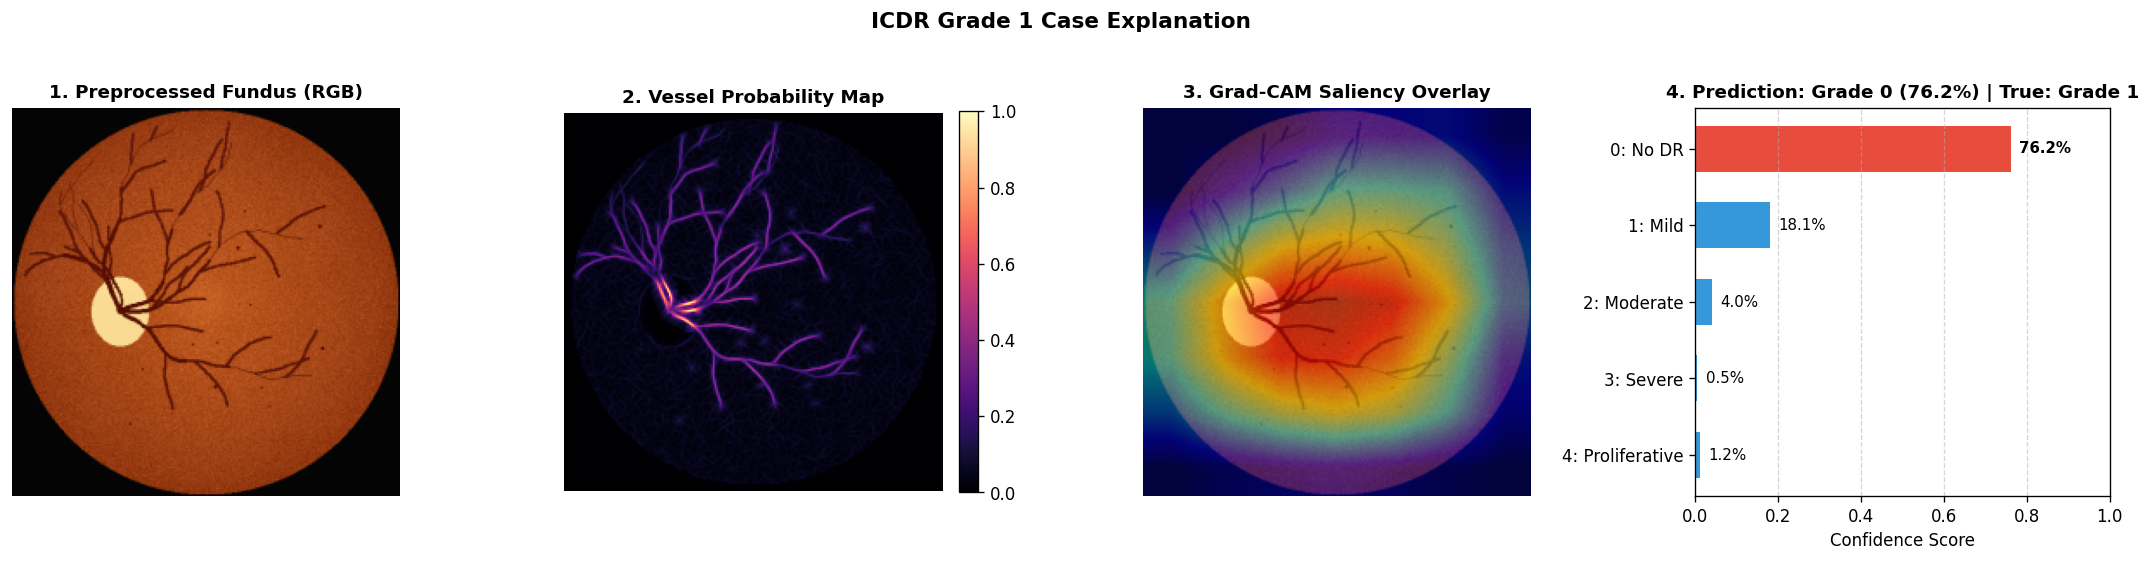

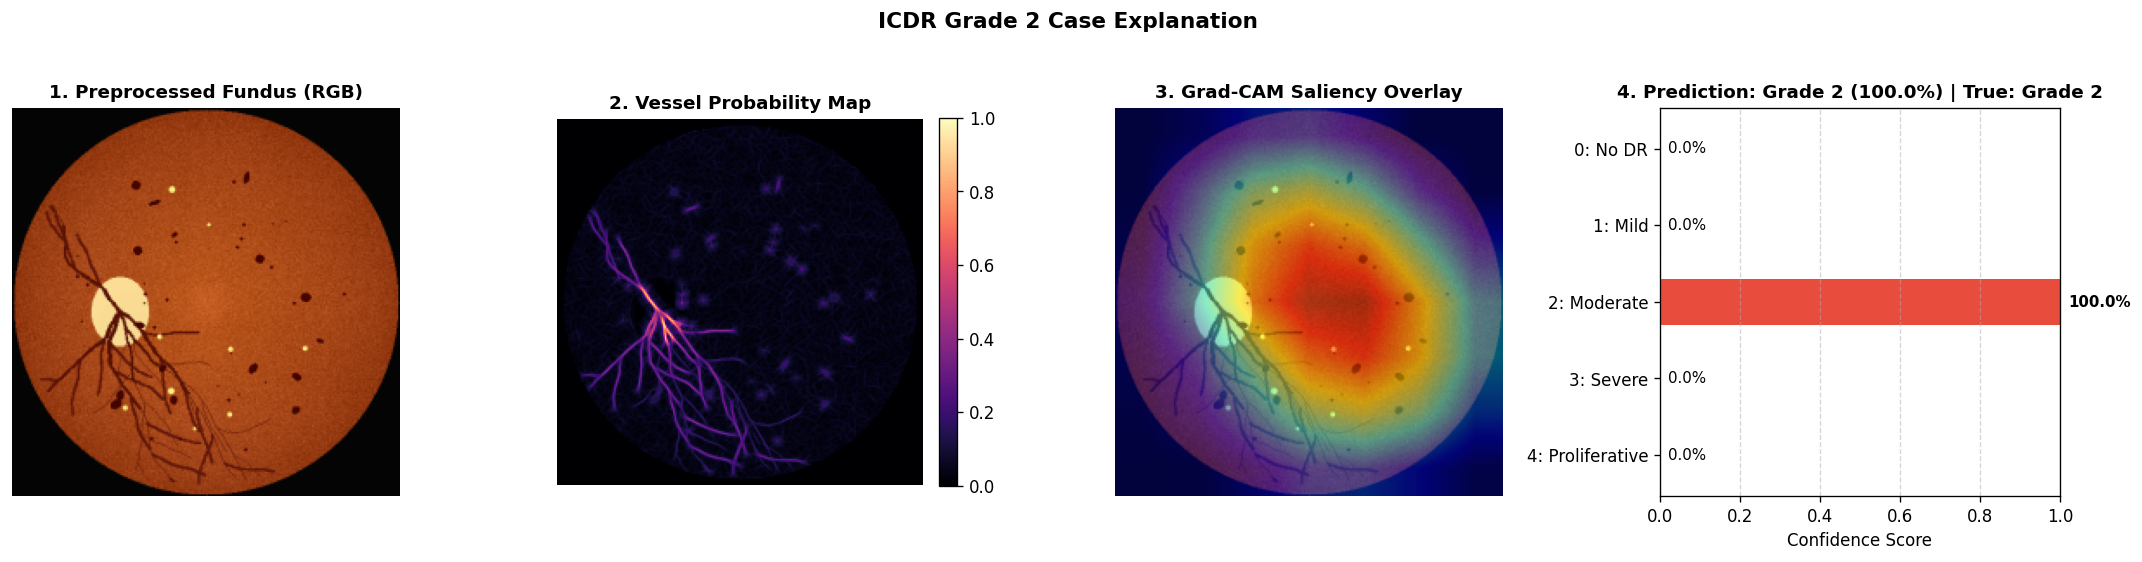

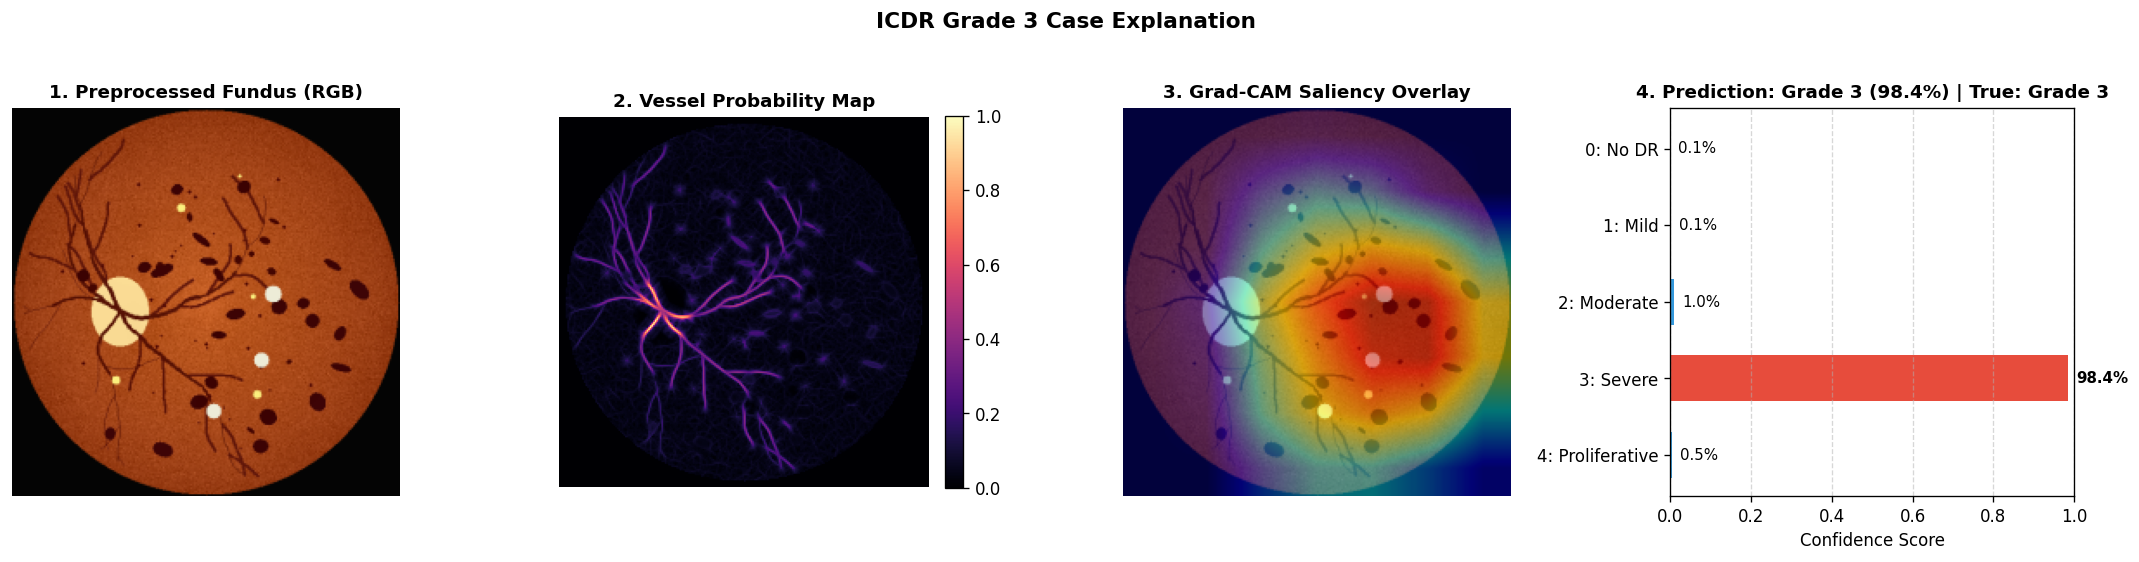

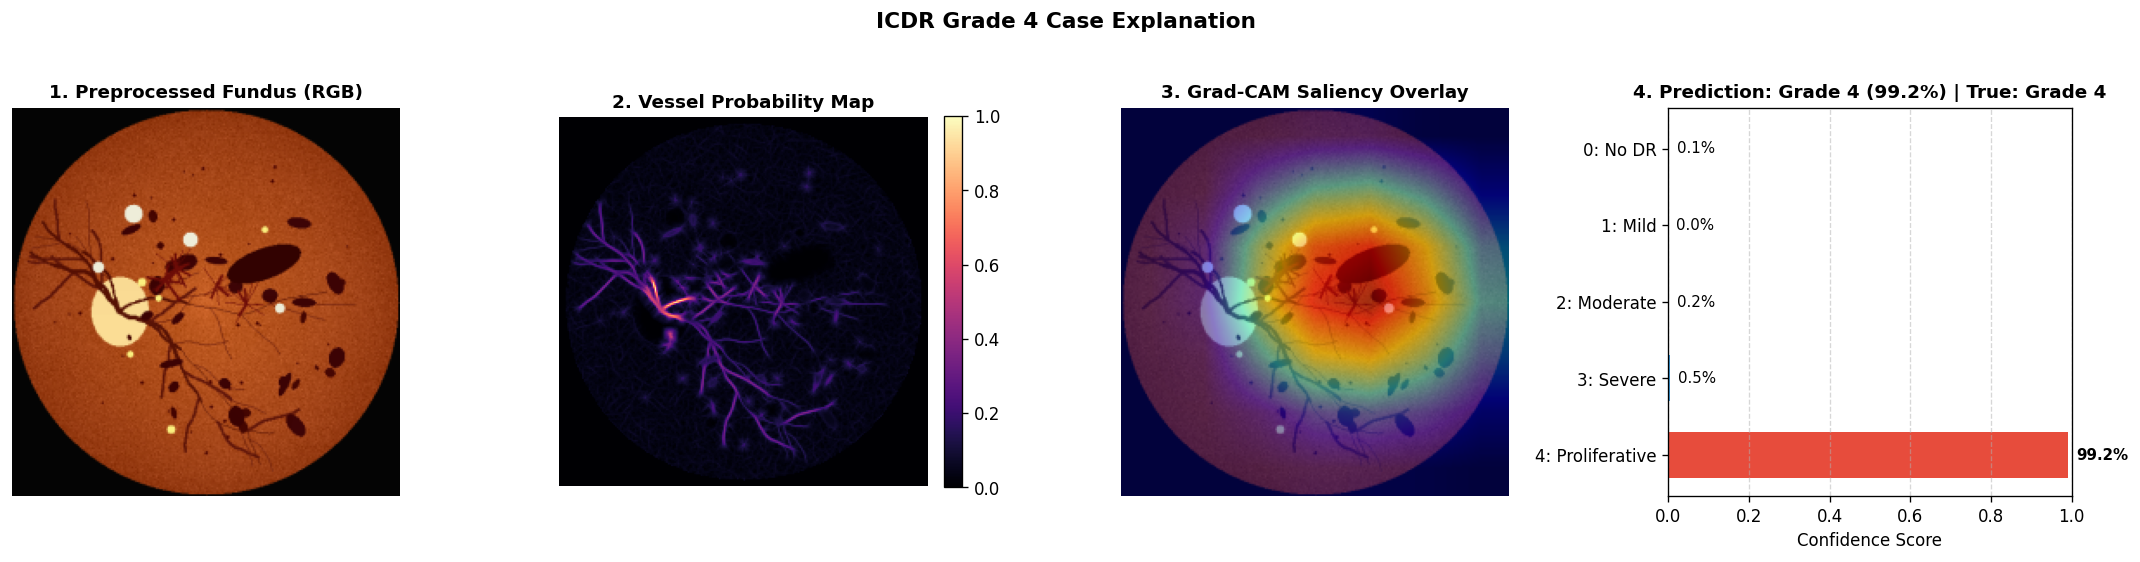

In [7]:
gradcam = GradCAM(vessel_model)

for grade in range(5):
    # Find a representative image of this grade
    row = df[df['diagnosis'] == grade].iloc[0]
    img_id = row['id_code']
    img_path = images_dir / f'{img_id}.png'
    
    # Preprocess RGB & Extract Vessel Map
    rgb_prep = preprocess_fundus(str(img_path), target_size=(224, 224))
    v_map = segmenter.get_vessel_map(rgb_prep, image_id=img_id, target_size=(224, 224))
    
    # Construct 4-channel tensor
    rgb_norm = (rgb_prep.astype(np.float32) / 255.0 - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    v_norm = (v_map - 0.150) / 0.250
    
    t_rgb = torch.from_numpy(rgb_norm.transpose(2, 0, 1)).float()
    t_v = torch.from_numpy(v_norm).unsqueeze(0).float()
    tensor_4ch = torch.cat([t_rgb, t_v], dim=0).unsqueeze(0).to(device)
    
    # Compute Grad-CAM
    cam_map, pred_class, confidence, probs = gradcam.generate_cam(tensor_4ch)
    overlay = overlay_cam_on_image(rgb_prep, cam_map, alpha=0.45)
    
    # Render 4-panel visual explanation
    fig = plot_prediction_explanation(
        original_rgb=rgb_prep,
        vessel_map=v_map,
        gradcam_overlay=overlay,
        probs=probs,
        true_grade=grade,
        pred_grade=pred_class,
        title=f'ICDR Grade {grade} Case Explanation'
    )
    plt.show()


## 6. Summary & Phase 1 MVP Conclusions

- **Completed Deliverables:**
  1. Automated Data Pipeline with Circular Crop and LAB CLAHE.
  2. Retinal Vasculature Segmentation & Probability Map Caching.
  3. 4-Channel Vessel-Aware Conv1 Weight Adaptation with Pretrained Weight Transfer.
  4. Training & Validation Pipeline with Class Imbalance Weighting.
  5. Explainable Grad-CAM Visualizations with multi-panel diagnostic summaries.

- **Next Steps (Phase 2):**
  - Scale pretraining on EyePACS and external validation on Messidor-2.
  - Incorporate Quadratic Weighted Kappa (QWK) and Ordinal/CORAL loss functions.
  - Dual-branch / Attention-gated fusion ablation studies.
  - Interactive Gradio / Streamlit clinician demo dashboard.